# Проблема синхронного приложения

В синхронном приложении код исполняется последовательно. Следующая строка кода выполняется после завершения предыдущей, и в каждый момент времени происходит что-то одно. Эта модель хорошо работает для большинства приложений. Но что, если какая-то одна строка кода занимает слишком много времени? В таком случае весь последующий код должен будет замереть, пока эта строка не соблаговолит завершиться. Многие из нас раньше встречали плохо написанные пользовательские интерфейсы, в которых все поначалу шло хорошо, а потом приложение внезапно зависало, оставляя нас созерцать крутящееся колесико или ждать хоть какого-нибудь ответа.

# IO Bound VS CPU Bound

Любая достаточно длительная операция может блокировать приложение, но особенно часто это бывает, когда приложение ждет завершения ввода-вывода.

1. **IO Bound (связанный с вводом-выводом)**: ввод-вывод выполняют такие устройства, как клавиатура, жесткий диск и, конечно же, сетевая карта. Такие операции ждут ввода от пользователя или получения содержимого от веб-API. В синхронном приложении мы будем ждать завершения операции и до тех пор ничего не сможем делать. Это ведет к проблемам с производительностью и отзывчивостью, поскольку в каждый момент времени может выполняться только одна длительная операция, а она не дает приложению больше ничего делать.
2. **CPU Bound (связанный с процессором)**: Это задачи, которые больше всего зависят от вычислительной мощности процессора. Это могут быть операции, которые требуют много вычислений, например, обработка больших объемов данных, выполнение математических вычислений и т. д. Приложение может потратить много времени на выполнение этих вычислений, что делает его медленным и менее отзывчивым.

Один из способов решения этой проблемы – ввести в программу конкурентность. Говоря по-простому, конкурентность позволяет одновременно выполнять более одной задачи. Примерами конкурентного ввода-вывода могут служить одновременная отправка не- скольких веб-запросов или создание одновременных подключений к веб-серверу.

# Конкурентность и параллелизм

## Конкурентность

Говоря, что две задачи выполняются конкурентно, мы имеем в виду, что они работают в одно и то же время. Взять, к примеру, пекаря, выпекающего два разных торта. Чтобы их испечь, нужно сначала разо- греть духовку. Разогрев может занимать десятки минут – это зависит от духовки и требуемой температуры, но нам необязательно ждать, пока духовка нагреется, поскольку можно в это время заняться другими делами, например смешать муку с сахаром и вбить в тесто яйца. Это можно делать, пока духовка звуковым сигналом не известит нас о том, что нагрелась.

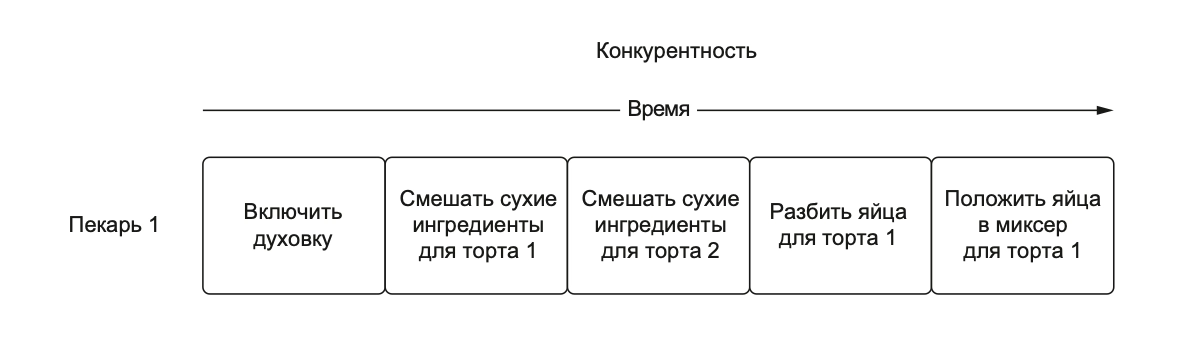

## Параллелизм

Хотя конкурентность подразумевает, что несколько задач выполняется одновременно, это еще не значит, что они работают параллельно. Говоря о *параллельной* работе, мы имеем в виду, что две задачи или более не просто чередуются, а выполняются строго в одно и то же время. 

Возвращаясь к примеру с тортами, представьте, что мы призвали на помощь второго пекаря. В этом случае мы можем трудиться над первым тортом, а помощник будет заниматься вторым. Два человека, готовящих тесто, работают параллельно, потому что одновременно делают два разных дела

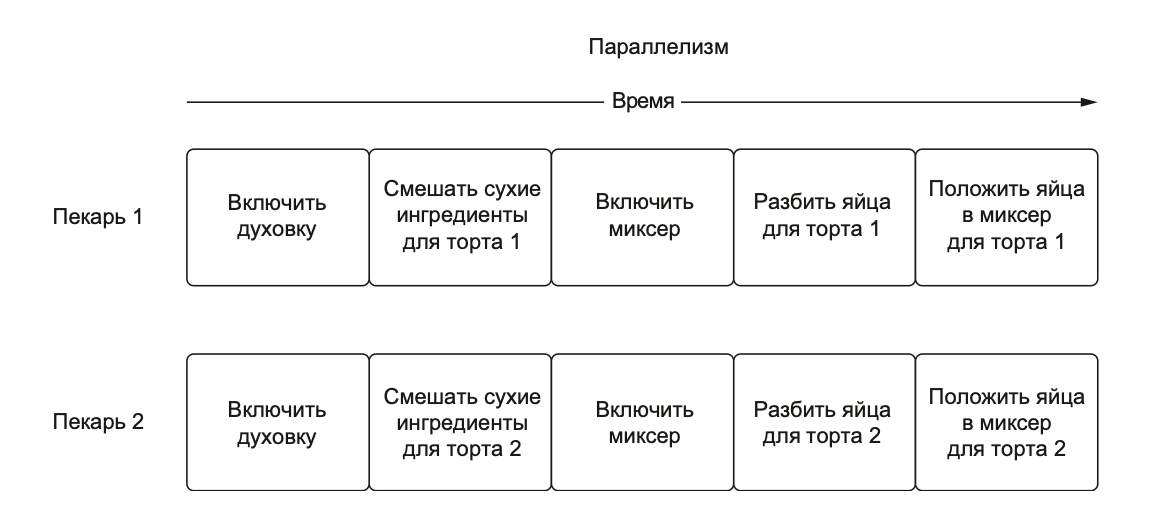

## Различие между конкурентностью и параллелизмом

Конкурентность возможна, когда несколько задач может работать независимо друг от друга. Конкурентность можно организовать, имея процессор всего с одним ядром, применив цикл событий для переключения между задачами. С другой стороны, параллелизм означает, что мы должны выполнять две задачи или более строго одновременно. На машине с одним ядром это невозможно, необходимо иметь процессор с несколькими ядрами.

# Процессы, потоки, многопоточность и многопроцессность

## Процесс

*Процессом* называется работающее приложение, которому выделена область памяти, недоступная другим приложениям. Пример создания Python-процесса – запуск простого приложения «hello world»

На одной машине может работать несколько процессов. Если машина оснащена процессором с несколькими ядрами, то несколько процессов могут работать одновременно. Если процессор имеет только одно ядро, то все равно можно выполнять несколько приложений конкурентно, но уже с применением квантования времени. При использовании квантования операционная система будет автоматически вытеснять работающий процесс по истечении некоторого промежутка времени и передавать процессор другому процессу. Алгоритмы, определяющие, в какой момент переключать процессы, зависят от операционной системы.

## Поток

Потоки можно представлять себе как облегченные процессы. Кроме того, это наименьшая единица выполнения, которая может управляться операционной системой. У потоков нет своей памяти, они пользуются памятью создавшего их процесса. Потоки ассоциированы с процессом, создавшим их. С каждым процессом всегда ассоциирован по меньшей мере один поток, обычно называемый *главным*. Процесс может создавать дополнительные потоки, которые обычно называются *рабочими* или *фоновыми*. Эти потоки могут конкурентно выполнять другую работу наряду с главным потоком. Потоки, как и процессы, могут работать параллельно на многоядерном процессе, и операционная система может переключаться между ними с помощью квантования времени. Обычное Python приложение создает процесс и главный поток, который отвечает за его выполнение.

# Глобальная блокировка интерпретатора

Глобальная блокировка интерпретатора (global interpreter lock – GIL) – тема, вызывающая споры в сообществе Python. Говоря кратко, GIL не дает Python-процессу исполнять более одной команды байт-кода в каждый момент времени.

П Р И М Е Ч А Н И Е: Многопроцессные приложения могут конкурентно выполнять несколько команд байт-кода, потому что у каждого Python-процесса своя собственная GIL.

Глобальная блокировка интерпретатора освобождается на время выполнения операций ввода-вывода. Это позволяет использовать потоки для конкурентного выполнения ввода-вывода, но не для выполнения счетного кода, написанного на Python

# Знакомство с сопрограммами

Сопрограмму можно рассматривать как обычную функцию Python, наделенную сверхспособностью: приостанавливаться, встретив операцию, для выполнения которой нужно заметное время. По завершении такой длительной операции сопрограмму можно «пробудить», после чего она продолжит выполнение. Пока приостановленная сопрограмма ждет завершения операции, мы можем выполнять другой код. Такое выполнение другого кода во время ожидания и обеспечивает конкурентность внутри приложения. Можно также одновременно выполнять несколько длительных операций, что еще больше повышает производительность приложения.

Для создания и приостановки сопрограммы нам придется использовать ключевые слова Python `async` и `await`. Слово `async` определяет сопрограмму, а слово `await` приостанавливает ее на время выполнения длительной операции.

## Создание сопрограмм с помощью ключевого слова async

Создать сопрограмму так же просто, как обычную функцию Python, только вместо ключевого слова def нужно использовать async def. Ключевое слово async говорит, что это сопрограмма, а не обычная функция.

In [3]:
import asyncio

async def my_coroutine() -> None:
    print('Hello world!')

async def coroutine_add_one(number: int) -> int: 
    return number + 1

def add_one(number: int) -> int:
    return number + 1


function_result = add_one(1) 
coroutine_result = coroutine_add_one(1)

print(f'Результат функции равен {function_result}, а его тип равен {type(function_result)}')
print(f'Результат сопрограммы равен {coroutine_result}, а его тип равен {type(coroutine_result)}')

Результат функции равен 2, а его тип равен <class 'int'>
Результат сопрограммы равен <coroutine object coroutine_add_one at 0x7c1828248d00>, а его тип равен <class 'coroutine'>


In [4]:
# asyncio.run() создаёт новый event loop — это работает в обычном .py скрипте.
# В Jupyter уже есть запущенный event loop (IPython его поднимает при старте),
# поэтому asyncio.run() падает с RuntimeError: cannot be called from a running event loop.
# Решение для Jupyter: await можно использовать прямо в ячейке без asyncio.run().

result = await coroutine_add_one(1)
print(result)  # 2

2


# КОНКУРЕНТНОСТЬ И ЕЕ ОТСУТСВИЕ (ниже есть примеры попроще и теория для закрепа)

In [31]:
import asyncio

async def delay(delay_seconds: int) -> int: 
    print(f'засыпаю на {delay_seconds} с')
    await asyncio.sleep(delay_seconds)
    print(f'сон в течение {delay_seconds} с закончился') 
    return delay_seconds

# Вариант 1: последовательное выполнение (без create_task)
async def main_sequential():
    sleep_for_three = await delay(3)   # main ждёт полного завершения delay(3)
    sleep_again    = await delay(2)    # только потом создаётся delay(2)
    sleep_once_more = await delay(1)   # и только потом delay(1)

await main_sequential()

засыпаю на 3 с
сон в течение 3 с закончился
засыпаю на 2 с
сон в течение 2 с закончился
засыпаю на 1 с
сон в течение 1 с закончился


**Вариант без `create_task` — последовательное выполнение (6 секунд)**

`sleep_for_three = await delay(3)` означает: "корутина `main` приостанавливается и ждёт, пока `delay(3)` не вернёт результат целиком".

Когда внутри `delay(3)` встречается `await asyncio.sleep(3)` — event loop действительно получает управление и готов запустить другие задачи. Но **других задач в очереди нет**: `delay(2)` ещё даже не создана, она появится в коде только после того, как `delay(3)` завершится. Поэтому loop просто ждёт.

Итог: три корутины выполняются **строго по очереди** — 3 + 2 + 1 = 6 секунд.

In [ ]:
import asyncio

async def delay(delay_seconds: int) -> int: 
    print(f'засыпаю на {delay_seconds} с')
    await asyncio.sleep(delay_seconds)
    print(f'сон в течение {delay_seconds} с закончился') 
    return delay_seconds

# Вариант 2: конкурентное выполнение (с create_task)
async def main_concurrent():
    sleep_for_three = asyncio.create_task(delay(3))  # таск запланирован, но ещё не стартовал
    sleep_again     = asyncio.create_task(delay(2))  # то же самое
    sleep_once_more = asyncio.create_task(delay(1))  # то же самое
    print('0')                                        # выполняется синхронно, ДО старта тасков (таски в фоне просто ждут своей очереди)
    await sleep_for_three                             # вот здесь loop запускает все три таска
    print('a')                                        # delay(2) и delay(1) к этому моменту уже готовы
    await sleep_again
    print('b')
    await sleep_once_more

await main_concurrent()

0
засыпаю на 3 с
засыпаю на 2 с
засыпаю на 1 с
сон в течение 1 с закончился
сон в течение 2 с закончился
сон в течение 3 с закончился
a
b


**Вариант с `create_task` — конкурентное выполнение (3 секунды)**

`create_task(delay(3))` не запускает корутину немедленно — он **планирует** её как задачу в очереди event loop. Таск существует, но не стартовал: `print('0')` выполняется раньше, чем хоть один таск напечатает "засыпаю".

Когда `main` доходит до `await sleep_for_three`, она приостанавливается — и теперь в очереди loop'а уже три запланированных таска. Loop запускает их все: они конкурентно печатают "засыпаю на X с", затем каждый приостанавливается на своём `await asyncio.sleep`. Loop крутит все три одновременно.

Порядок вывода:
```
0
засыпаю на 3 с   ← loop запустил таски только после await в main
засыпаю на 2 с
засыпаю на 1 с
сон в течение 1 с закончился  ← через 1 сек
сон в течение 2 с закончился  ← через 2 сек
сон в течение 3 с закончился  ← через 3 сек
a                              ← main resume после sleep_for_three
b                              ← sleep_again и sleep_once_more уже готовы, await мгновенный
```

**Ключевое различие между вариантами** — не в поведении `await`, а в том, **есть ли в очереди другие задачи**. `await` в обоих случаях одинаково приостанавливает текущую корутину и передаёт управление loop'у. Разница в том, что `create_task` заранее кладёт задачи в очередь, и loop есть чем заняться во время ожидания. Без `create_task` очередь пустая.

Короткая схема:


asyncio.run()          →  создаёт loop и запускает корутину

await внутри корутины  →  передаёт управление loop'у пока ждёшь

loop                   →  решает, какую корутину (таску) разбудить следующей


# Приостановка выполнения с помощью ключевого слова await


In [6]:
import asyncio

async def add_one(number: int) -> int: 
		return number + 1

async def main() -> None: 
		one_plus_one = await add_one(1)  # Приостановиться и ждать результата add_one(1)
		two_plus_one = await add_one(2)  # Приостановиться и ждать результата add_one(2)
		print(one_plus_one) 
		print(two_plus_one)

await main() # asyncio.run(main())

2
3


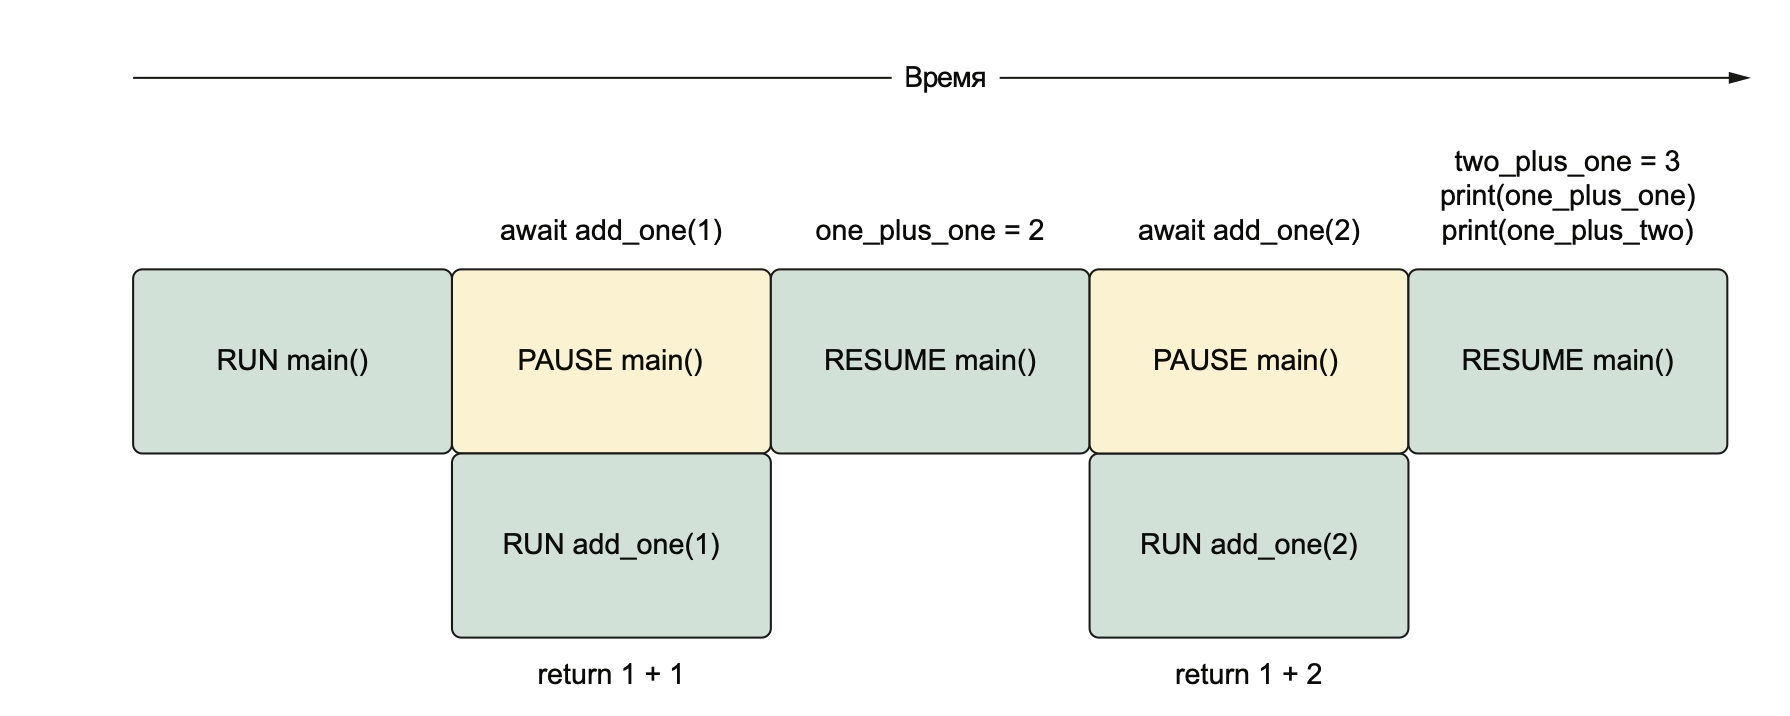

Встретив выражение await, интерпретатор приостанавливает родительскую сопрограмму и выполняет сопрограмму в выражении await. По ее завершении родительская сопрограмма приостанавливается и возвращенное ей значение присваивается переменной

Этот код работает так же, как обычный последовательный код

# Конкурентное выполнение с помощью задач

Задача – это обертка вокруг сопрограммы, которая планирует выполнение последней в цикле событий как можно раньше. И планирование, и выполнение происходят в неблокирующем режиме, т. е., создав задачу, мы можем сразу приступить к выполнению другого кода, пока эта задача работает в фоне. Сравните с ключевым словом `await`, которое блокирует выполнение, т. е. мы приостанавливаем всю сопрограмму на время, пока выражение `await` не вернет управление.

Способность создавать задачи и планировать их для немедленного выполнения в цикле событий означает, что несколько задач может работать приблизительно в одно и то же время. Пока одна задача выполняет длительную операцию, другие могут работать конкурентно. Для иллюстрации создадим две задачи и попробуем выполнить их одновременно.

## Основы создания задач

Для создания задачи служит функция `asyncio.create_task`. Ей передается подлежащая выполнению сопрограмма, а в ответ она немедленно возвращает объект задачи. Этот объект можно включить в выражение `await`, которое извлечет возвращенное значение по завершении задачи.

In [11]:
import asyncio

async def delay(delay_seconds: int) -> int: 
		print(f'засыпаю на {delay_seconds} с')
		await asyncio.sleep(delay_seconds)
		print(f'сон в течение {delay_seconds} с закончился') 
		return delay_seconds

async def main():
		sleep_for_three = asyncio.create_task(delay(3))
		print(type(sleep_for_three))  # практически мгновенно переходим к этой строке
		result = await sleep_for_three
		print(result)


await main() # asyncio.run(main())

<class '_asyncio.Task'>
засыпаю на 3 с
сон в течение 3 с закончился
3


ДЛЯ СРАВНЕНИЯ:

In [ ]:
import asyncio

async def delay(delay_seconds: int) -> int: 
		print(f'засыпаю на {delay_seconds} с')
		await asyncio.sleep(delay_seconds)
		print(f'сон в течение {delay_seconds} с закончился') 
		return delay_seconds

async def main():
		sleep_for_three = asyncio.create_task(delay(3))
		await asyncio.sleep(4)  # имитируем какую-то работу, которая занимает 4 секунды
		print(type(sleep_for_three))  # приходит ПОЗЖЕ, чем принты sleep_for_three, так как asyncio.create_task запускает сопрограмму в фоне, а не блокирует выполнение текущей сопрограммы. Мы остались в том же event loop и await asyncio.sleep(4), пока мы спим, позволяет другим задачам выполняться, в том числе и sleep_for_three, который в это время выполняется и печатает свои принты.
		result = await sleep_for_three
		print(result)


await main() # asyncio.run(main())

засыпаю на 3 с
сон в течение 3 с закончился
<class '_asyncio.Task'>
3


In [ ]:
import asyncio

async def delay(delay_seconds: int) -> int: 
		print(f'засыпаю на {delay_seconds} с')
		await asyncio.sleep(delay_seconds)
		print(f'сон в течение {delay_seconds} с закончился') 
		return delay_seconds

async def main():
		sleep_for_three = asyncio.create_task(delay(3))
		print(type(sleep_for_three))  # практически мгновенно переходим к этой строке, пока в фоне выполняется delay(3)
		await asyncio.sleep(4)  # имитируем какую-то работу, которая занимает 4 секунды, до завершения которой delay(3) успевает выполниться и напечатать свои принты в фоне.
		result = await sleep_for_three
		print(result)


await main() # asyncio.run(main())

<class '_asyncio.Task'>
засыпаю на 3 с
сон в течение 3 с закончился
3


# Конкурентное выполнение нескольких задач:

In [25]:
import asyncio

async def delay(delay_seconds: int) -> int: 
		print(f'засыпаю на {delay_seconds} с')
		await asyncio.sleep(delay_seconds)
		print(f'сон в течение {delay_seconds} с закончился') 
		return delay_seconds

async def main():
		sleep_for_three = asyncio.create_task(delay(3)) 
		sleep_again = asyncio.create_task(delay(2)) 
		sleep_once_more = asyncio.create_task(delay(1))
		print('0')
		await sleep_for_three
		print('a')
		await sleep_again
		print('b')
		await sleep_once_more


await main() # asyncio.run(main())

0
засыпаю на 3 с
засыпаю на 2 с
засыпаю на 1 с
сон в течение 1 с закончился
сон в течение 2 с закончился
сон в течение 3 с закончился
a
b


In [29]:
import asyncio

async def delay(delay_seconds: int) -> int: 
		print(f'засыпаю на {delay_seconds} с')
		await asyncio.sleep(delay_seconds)
		print(f'сон в течение {delay_seconds} с закончился') 
		return delay_seconds

async def main():
		sleep_for_three = asyncio.create_task(delay(3)) 
		sleep_again = asyncio.create_task(delay(1)) 
		sleep_once_more = asyncio.create_task(delay(1))
		print('0')
		await sleep_once_more
		print('a')
		await sleep_again
		print('b')
		await sleep_for_three


await main() # asyncio.run(main())

0
засыпаю на 3 с
засыпаю на 1 с
засыпаю на 1 с
сон в течение 1 с закончился
сон в течение 1 с закончился
a
b
сон в течение 3 с закончился


In [24]:
import asyncio

async def delay(delay_seconds: int) -> int: 
		print(f'засыпаю на {delay_seconds} с')
		await asyncio.sleep(delay_seconds)
		print(f'сон в течение {delay_seconds} с закончился') 
		return delay_seconds

async def main():
		sleep_for_three = asyncio.create_task(delay(3)) 
		sleep_again = asyncio.create_task(delay(2)) 
		sleep_once_more = asyncio.create_task(delay(1))
		await asyncio.sleep(1)  # имитируем какую-то работу, которая занимает 1 секунду, до завершения которой delay(1) успевает выполниться и напечатать свои принты в фоне.
		print('0')
		await sleep_for_three
		print('a')
		await sleep_again
		print('b')
		await sleep_once_more


await main() # asyncio.run(main())

засыпаю на 3 с
засыпаю на 2 с
засыпаю на 1 с
0
сон в течение 1 с закончился
сон в течение 2 с закончился
сон в течение 3 с закончился
a
b


In [22]:
import asyncio

async def delay(delay_seconds: int) -> int: 
		print(f'засыпаю на {delay_seconds} с')
		await asyncio.sleep(delay_seconds)
		print(f'сон в течение {delay_seconds} с закончился') 
		return delay_seconds

async def main():
		sleep_for_three = await delay(3) 
		sleep_again = await delay(2) 
		sleep_once_more = await delay(1)
		await sleep_for_three
		await sleep_again 
		await sleep_once_more


await main() # asyncio.run(main())

засыпаю на 3 с
сон в течение 3 с закончился
засыпаю на 2 с
сон в течение 2 с закончился
засыпаю на 1 с
сон в течение 1 с закончился


TypeError: object int can't be used in 'await' expression

In [30]:
import asyncio

async def delay(delay_seconds: int) -> int: 
		print(f'засыпаю на {delay_seconds} с')
		await asyncio.sleep(delay_seconds)
		print(f'сон в течение {delay_seconds} с закончился') 
		return delay_seconds

async def main():
		sleep_for_three = await delay(3) 
		sleep_again = await delay(2) 
		sleep_once_more = await delay(1)
		await sleep_once_more
		await sleep_again 
		await sleep_for_three


await main() # asyncio.run(main())

засыпаю на 3 с
сон в течение 3 с закончился
засыпаю на 2 с
сон в течение 2 с закончился
засыпаю на 1 с
сон в течение 1 с закончился


TypeError: object int can't be used in 'await' expression

Ещё 1 пример:

In [38]:
import asyncio

async def delay(delay_seconds: int) -> int:
    print(f'засыпаю на {delay_seconds} с')
    await asyncio.sleep(delay_seconds)
    print(f'сон в течение {delay_seconds} с закончился')
    return delay_seconds

async def hello_every_second():
    for i in range(2):
        await asyncio.sleep(1)
        print("пока я жду, исполняется другой код!")

async def main():
    first_delay = asyncio.create_task(delay(3))
    second_delay = asyncio.create_task(delay(3))
    await hello_every_second()
    await first_delay
    await second_delay


await main() # asyncio.run(main())


засыпаю на 3 с
засыпаю на 3 с
пока я жду, исполняется другой код!
пока я жду, исполняется другой код!
сон в течение 3 с закончился
сон в течение 3 с закончился


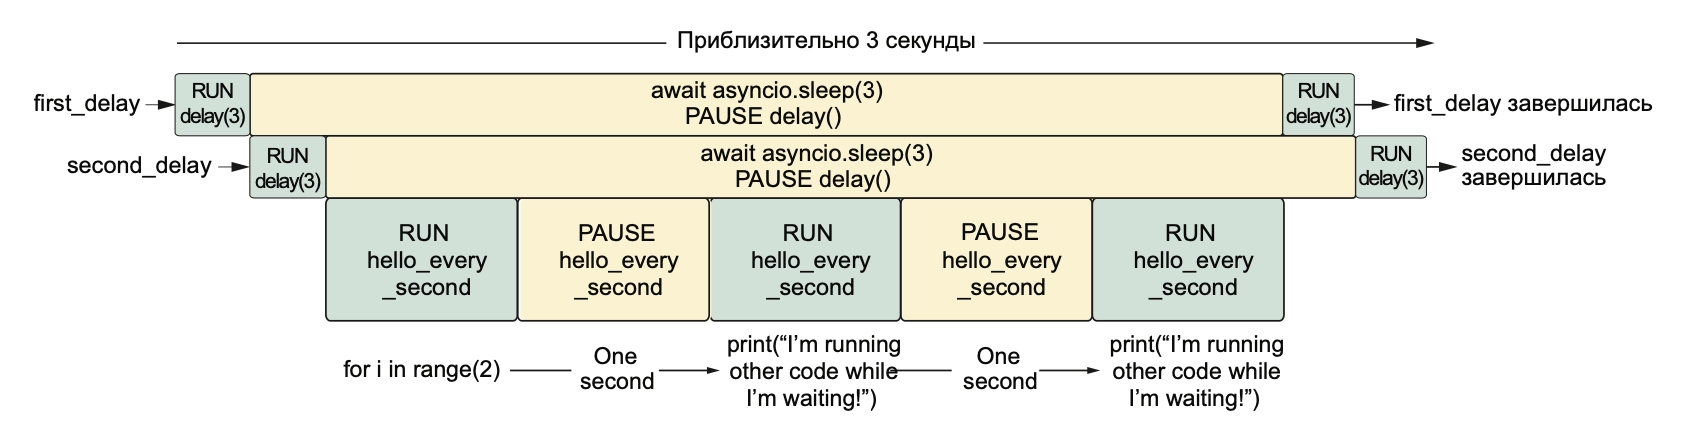

# Запуск нескольких задач с помощью wait и gather

### `wait`

Функция `asyncio.wait()` принимает **список** асинхронных задач в качестве аргумента и запускает их одновременно. 

Она возвращает кортеж из двух множеств: множество выполненных задач и множество невыполненных задач.

In [40]:
import asyncio
import time


async def delay(delay_seconds: int) -> int:
    print(f'засыпаю на {delay_seconds} с')
    await asyncio.sleep(delay_seconds)
    print(f'сон в течение {delay_seconds} с закончился')
    return delay_seconds


async def main():
    t1 = time.time()
    await asyncio.wait([
        asyncio.create_task(delay(3)),
        asyncio.create_task(delay(2)),
        asyncio.create_task(delay(1)),
    ])
    t2 = time.time()
    print(t2 - t1)

await main() # asyncio.run(main())

засыпаю на 3 с
засыпаю на 2 с
засыпаю на 1 с
сон в течение 1 с закончился
сон в течение 2 с закончился
сон в течение 3 с закончился
3.002943992614746


### `gather`

Функция `asyncio.gather()` принимает список асинхронных задач в качестве аргументов и запускает их одновременно. 

Она возвращает список результатов, соответствующих выполненным задачам в том же порядке, в котором задачи были переданы в функцию.

In [42]:
import asyncio
import time

async def delay(delay_seconds: int) -> int: 
		print(f'засыпаю на {delay_seconds} с')
		await asyncio.sleep(delay_seconds)
		print(f'сон в течение {delay_seconds} с закончился') 
		return delay_seconds

async def main():
    t1 = time.time()
    await asyncio.gather(
        asyncio.create_task(delay(3)),
        asyncio.create_task(delay(2)),
        asyncio.create_task(delay(1)),
    )
    t2 = time.time()
    print(t2 - t1)

await main() # asyncio.run(main())

засыпаю на 3 с
засыпаю на 2 с
засыпаю на 1 с
сон в течение 1 с закончился
сон в течение 2 с закончился
сон в течение 3 с закончился
3.005690574645996


## Обработка исключений

### `wait`

Если во время выполнения задачи возникает исключение, `asyncio.wait()`
**ПРОДОЛЖАЕТ** выполнение остальных задач и не выбрасывает исключение.

На строчке `asyncio.run(main())` нельзя перехватить исключение. Перехватывать исключения нужно с помощью `as_completed`

In [46]:
import asyncio
import time

async def delay(delay_seconds: int) -> int: 
    print(f'засыпаю на {delay_seconds} с')
    await asyncio.sleep(delay_seconds)

    if delay_seconds == 2:
        raise ValueError('Моё собственное исключение')

    print(f'сон в течение {delay_seconds} с закончился') 
    return delay_seconds

async def main():
    t1 = time.time()
    await asyncio.wait([
        asyncio.create_task(delay(1)),
        asyncio.create_task(delay(2)),
        asyncio.create_task(delay(3)),
    ])
    t2 = time.time()
    print(t2 - t1)


await main() # asyncio.run(main())

засыпаю на 1 с
засыпаю на 2 с
засыпаю на 3 с
сон в течение 1 с закончился


Task exception was never retrieved
future: <Task finished name='Task-361' coro=<delay() done, defined at /tmp/ipykernel_6146/2074670628.py:4> exception=ValueError('Моё собственное исключение')>
Traceback (most recent call last):
  File "/tmp/ipykernel_6146/2074670628.py", line 9, in delay
    raise ValueError('Моё собственное исключение')
ValueError: Моё собственное исключение


сон в течение 3 с закончился
3.009021520614624


### `as_completed`

In [48]:
import asyncio
import time

async def delay(delay_seconds: int) -> int: 
    print(f'засыпаю на {delay_seconds} с')
    await asyncio.sleep(delay_seconds)

    if delay_seconds == 2:
        raise ValueError('Моё собственное исключение')

    print(f'сон в течение {delay_seconds} с закончился') 
    return delay_seconds

async def main():
    t1 = time.time()

    tasks = [
        asyncio.create_task(delay(1)),
        asyncio.create_task(delay(2)),
        asyncio.create_task(delay(3)),
    ]

    for completed_task in asyncio.as_completed(tasks):
        try:
            await completed_task
        except ValueError:
            print(f'Caught ValueError in task: {completed_task}')
    t2 = time.time()
    print(t2 - t1)


await main() # asyncio.run(main())

засыпаю на 1 с
засыпаю на 2 с
засыпаю на 3 с
сон в течение 1 с закончился
Caught ValueError in task: <coroutine object as_completed.<locals>._wait_for_one at 0x7c1818ce2dc0>
сон в течение 3 с закончился
3.00730562210083


wait не входит в as_completed — у wait есть эксклюзивная возможность return_when, которой у as_completed нет. Если нужна реакция на первую ошибку с возможностью отменить остальные таски — только wait.

### `gather`

Если во время выполнения задачи возникает исключение, asyncio.gather() прекращает выполнение остальных задач и сразу же выбрасывает исключение.

In [50]:

import asyncio
import time

async def delay(delay_seconds: int) -> int: 
    print(f'засыпаю на {delay_seconds} с')
    await asyncio.sleep(delay_seconds)

    if delay_seconds == 2:
        raise ValueError('Моё собственное исключение')

    print(f'сон в течение {delay_seconds} с закончился') 
    return delay_seconds

async def main():
    t1 = time.time()
    await asyncio.gather(
        asyncio.create_task(delay(1)),
        asyncio.create_task(delay(2)),
        asyncio.create_task(delay(3)),
    )
    t2 = time.time()
    print(t2 - t1)


await main() # asyncio.run(main())

засыпаю на 1 с
засыпаю на 2 с
засыпаю на 3 с
сон в течение 1 с закончился


ValueError: Моё собственное исключение

сон в течение 3 с закончился


## Обработка результата

### `wait`

In [54]:
import asyncio
import time

async def delay(delay_seconds: int) -> int: 
    print(f'засыпаю на {delay_seconds} с')
    await asyncio.sleep(delay_seconds)
    print(f'сон в течение {delay_seconds} с закончился') 
    return delay_seconds

async def main():
    t1 = time.time()

    tasks = [
        asyncio.create_task(delay(1)),
        asyncio.create_task(delay(2)),
        asyncio.create_task(delay(3)),
    ]

    done, pending = await asyncio.wait(tasks)

    print('-------------------------------------------')
    print('Done:')
    for d in done:
        print(d, '|', d.result())
    print('Pending:')
    for p in pending:
        print(p)
    print('-------------------------------------------')

    # print('*******************************************')
    # for task in tasks:
    #     print(task.result())
    # print('*******************************************')

    t2 = time.time()
    print(t2 - t1)

await main() # asyncio.run(main())

засыпаю на 1 с
засыпаю на 2 с
засыпаю на 3 с
сон в течение 1 с закончился
сон в течение 2 с закончился
сон в течение 3 с закончился
-------------------------------------------
Done:
<Task finished name='Task-408' coro=<delay() done, defined at /tmp/ipykernel_6146/2757839830.py:4> result=1> | 1
<Task finished name='Task-410' coro=<delay() done, defined at /tmp/ipykernel_6146/2757839830.py:4> result=3> | 3
<Task finished name='Task-409' coro=<delay() done, defined at /tmp/ipykernel_6146/2757839830.py:4> result=2> | 2
Pending:
-------------------------------------------
3.003598213195801


### `as_completed`

In [56]:
import asyncio
import time

async def delay(delay_seconds: int) -> int: 
    print(f'засыпаю на {delay_seconds} с')
    await asyncio.sleep(delay_seconds)

    if delay_seconds == 2:
        raise ValueError('Моё собственное исключение')

    print(f'сон в течение {delay_seconds} с закончился') 
    return delay_seconds

async def main():
    t1 = time.time()

    tasks = [
        asyncio.create_task(delay(1)),
        asyncio.create_task(delay(2)),
        asyncio.create_task(delay(3)),
    ]

    for coro in asyncio.as_completed(tasks):
        try:
            result = await coro       # as_completed отдаёт корутины, не таски
            print(result)
        except ValueError as e:
            print(f'Ошибка: {e} → 0')
            result = 0
            print(result)

    t2 = time.time()
    print(f'Время: {t2 - t1:.2f} с')


await main()

засыпаю на 1 с
засыпаю на 2 с
засыпаю на 3 с
сон в течение 1 с закончился
1
Ошибка: Моё собственное исключение → 0
0
сон в течение 3 с закончился
3
Время: 3.00 с


### `gather`

In [57]:
import asyncio
import time

async def delay(delay_seconds: int) -> int: 
		print(f'засыпаю на {delay_seconds} с')
		await asyncio.sleep(delay_seconds)
		print(f'сон в течение {delay_seconds} с закончился') 
		return delay_seconds

async def main():
    t1 = time.time()
    results = await asyncio.gather(
        asyncio.create_task(delay(1)),
        asyncio.create_task(delay(2)),
        asyncio.create_task(delay(3)),
    )

    print('-------------------------------------------')
    print(results)
    for result in results:
        print(result)
    print('-------------------------------------------')

    t2 = time.time()
    print(t2 - t1)


await main() # asyncio.run(main())

засыпаю на 1 с
засыпаю на 2 с
засыпаю на 3 с
сон в течение 1 с закончился
сон в течение 2 с закончился
сон в течение 3 с закончился
-------------------------------------------
[1, 2, 3]
1
2
3
-------------------------------------------
3.0075416564941406


## Динамическое создание тасков

### `wait`

In [58]:
import asyncio
import time

async def delay(delay_seconds: int) -> int: 
		print(f'засыпаю на {delay_seconds} с')
		await asyncio.sleep(delay_seconds)
		print(f'сон в течение {delay_seconds} с закончился') 
		return delay_seconds

async def main():
    t1 = time.time()

    tasks = []
    for i in range(1, 6):
        tasks.append(asyncio.create_task(delay(i)))

    await asyncio.wait(tasks)

    print('-------------------------------------------')
    for task in tasks:
        print(task.result())
    print('-------------------------------------------')

    t2 = time.time()
    print(t2 - t1)


await main() # asyncio.run(main())

засыпаю на 1 с
засыпаю на 2 с
засыпаю на 3 с
засыпаю на 4 с
засыпаю на 5 с
сон в течение 1 с закончился
сон в течение 2 с закончился
сон в течение 3 с закончился
сон в течение 4 с закончился
сон в течение 5 с закончился
-------------------------------------------
1
2
3
4
5
-------------------------------------------
5.0039262771606445


### `gather`

In [59]:
import asyncio
import time

async def delay(delay_seconds: int) -> int: 
		print(f'засыпаю на {delay_seconds} с')
		await asyncio.sleep(delay_seconds)
		print(f'сон в течение {delay_seconds} с закончился') 
		return delay_seconds

async def main():
    t1 = time.time()
    tasks = []
    for i in range(1, 6):
        tasks.append(asyncio.create_task(delay(i)))

    results = await asyncio.gather(*tasks)

    print('-------------------------------------------')
    for result in results:
        print(result)
    print('-------------------------------------------')

    t2 = time.time()
    print(t2 - t1)


await main() # asyncio.run(main())

засыпаю на 1 с
засыпаю на 2 с
засыпаю на 3 с
засыпаю на 4 с
засыпаю на 5 с
сон в течение 1 с закончился
сон в течение 2 с закончился
сон в течение 3 с закончился
сон в течение 4 с закончился
сон в течение 5 с закончился
-------------------------------------------
1
2
3
4
5
-------------------------------------------
5.002089023590088
